# 04 — Temporal Dynamics Within Epoch

Explores variance and signal structure over time within the 1 s epoch. Relevant to **within-epoch CPD** (DATASET_GUIDE §8A): "Is there a time where the mean/slope/variance shifts?" Informs feature window size and when to expect transitions (e.g., P1/N1 ~100–200 ms).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
DATA_ROOT = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts" / "figures" / "temporal_dynamics"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PARTICIPANTS = [f"sub-{i:02d}" for i in range(1, 11)]
DATE_TAG = "2026-02-25"

In [2]:
def load_preprocessed(path):
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

## 1. Variance over time within epoch

Per timepoint: variance across conditions and repetitions (channel-averaged). When does signal "kick in"?

In [3]:
var_over_time_rows = []
for sub in PARTICIPANTS:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, times = load_preprocessed(p)
    ch_avg = X.mean(axis=2)
    var_t = ch_avg.var(axis=(0, 1))
    for i, t in enumerate(times):
        var_over_time_rows.append({"participant": sub, "time_ms": float(t) * 1000, "time_idx": i, "var": var_t[i]})

var_time_df = pd.DataFrame(var_over_time_rows)

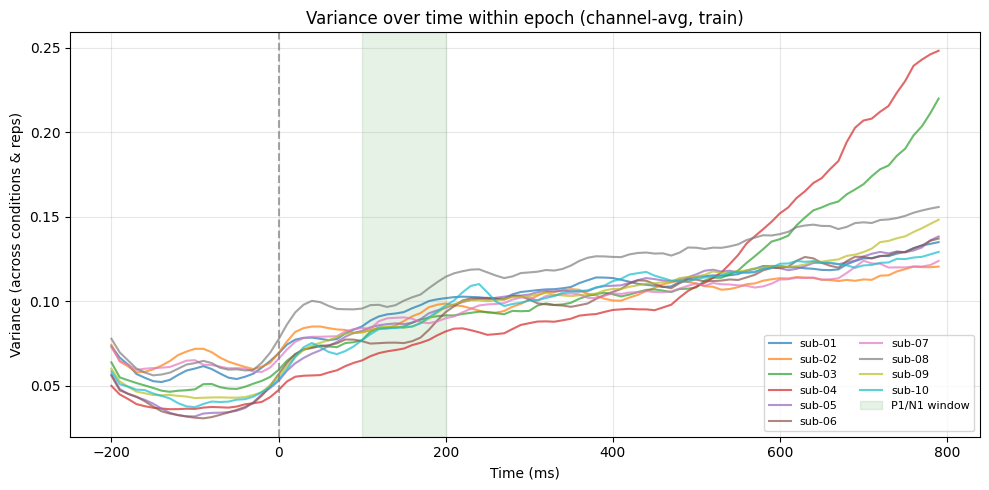

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for sub in PARTICIPANTS:
    d = var_time_df[var_time_df["participant"] == sub]
    ax.plot(d["time_ms"], d["var"], alpha=0.7, label=sub)
ax.axvline(0, color="gray", ls="--", alpha=0.7)
ax.axvspan(100, 200, alpha=0.1, color="green", label="P1/N1 window")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Variance (across conditions & reps)")
ax.set_title("Variance over time within epoch (channel-avg, train)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"temporal__variance_over_time__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Mean amplitude over time (grand average)

Grand-average ERP shape; identify peak latencies.

In [5]:
mean_over_time_rows = []
for sub in PARTICIPANTS:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, times = load_preprocessed(p)
    mean_t = X.mean(axis=(0, 1, 2))
    for i, t in enumerate(times):
        mean_over_time_rows.append({"participant": sub, "time_ms": float(t) * 1000, "mean": mean_t[i]})

mean_time_df = pd.DataFrame(mean_over_time_rows)

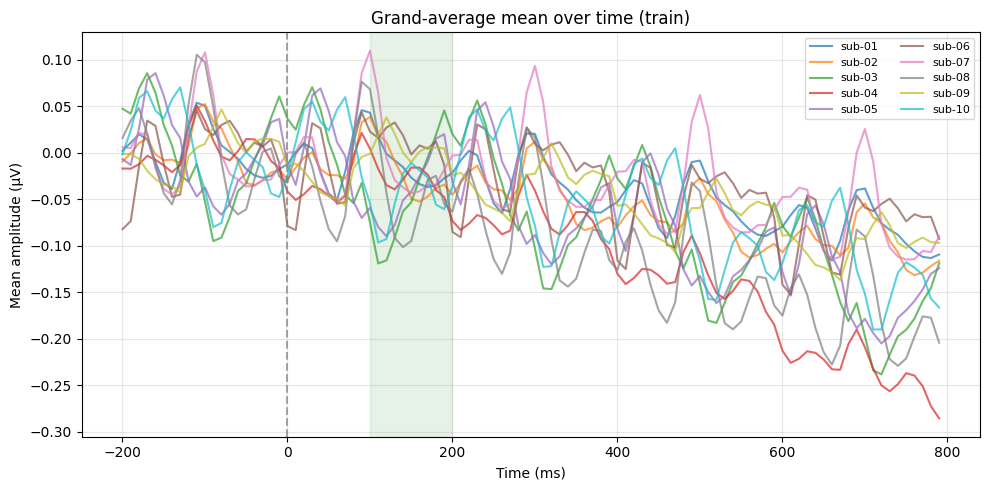

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for sub in PARTICIPANTS:
    d = mean_time_df[mean_time_df["participant"] == sub]
    ax.plot(d["time_ms"], d["mean"], alpha=0.7, label=sub)
ax.axvline(0, color="gray", ls="--", alpha=0.7)
ax.axvspan(100, 200, alpha=0.1, color="green")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Mean amplitude (µV)")
ax.set_title("Grand-average mean over time (train)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"temporal__mean_over_time__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Peak latency (max variance timepoint per participant)

In [7]:
peak_rows = []
for sub in PARTICIPANTS:
    d = var_time_df[var_time_df["participant"] == sub]
    idx_max = d["var"].idxmax()
    peak_rows.append({
        "participant": sub,
        "peak_time_ms": d.loc[idx_max, "time_ms"],
        "peak_var": d.loc[idx_max, "var"],
    })

peak_df = pd.DataFrame(peak_rows)
tables_dir = ROOT / "artifacts" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
peak_df.to_csv(tables_dir / f"temporal__peak_variance_latency__{DATE_TAG}.csv", index=False)
print(peak_df.to_string(index=False))

participant  peak_time_ms  peak_var
     sub-01         790.0  0.134922
     sub-02         760.0  0.120446
     sub-03         790.0  0.219858
     sub-04         790.0  0.248156
     sub-05         790.0  0.138257
     sub-06         790.0  0.137029
     sub-07         700.0  0.123890
     sub-08         790.0  0.155692
     sub-09         790.0  0.148151
     sub-10         790.0  0.129127


## 4. Variance by time window (baseline vs post-stimulus)

Compare baseline (-200 to 0 ms) vs early (0–200 ms) vs late (200–800 ms).

In [8]:
window_rows = []
for sub in PARTICIPANTS:
    d = var_time_df[var_time_df["participant"] == sub]
    bl = (d["time_ms"] >= -200) & (d["time_ms"] < 0)
    er = (d["time_ms"] >= 0) & (d["time_ms"] < 200)
    lt = (d["time_ms"] >= 200) & (d["time_ms"] <= 800)
    window_rows.append({
        "participant": sub,
        "baseline_var": d.loc[bl, "var"].mean(),
        "early_var": d.loc[er, "var"].mean(),
        "late_var": d.loc[lt, "var"].mean(),
    })

window_df = pd.DataFrame(window_rows)
window_df.to_csv(tables_dir / f"temporal__variance_by_window__{DATE_TAG}.csv", index=False)
print(window_df.to_string(index=False))

participant  baseline_var  early_var  late_var
     sub-01      0.058625   0.085550  0.114861
     sub-02      0.064632   0.084850  0.107782
     sub-03      0.050671   0.078086  0.126925
     sub-04      0.039012   0.064314  0.132718
     sub-05      0.039096   0.078326  0.114778
     sub-06      0.038472   0.074404  0.112705
     sub-07      0.061876   0.082553  0.108415
     sub-08      0.062281   0.097389  0.132366
     sub-09      0.045806   0.078957  0.115683
     sub-10      0.044164   0.076632  0.114005


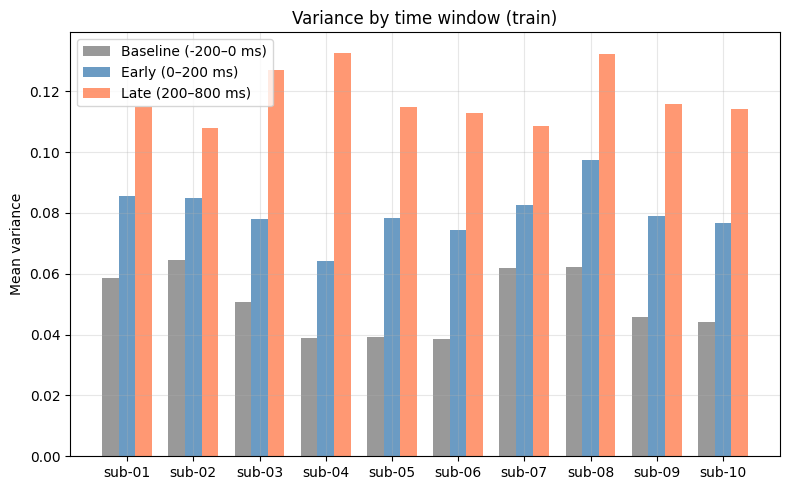

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PARTICIPANTS))
w = 0.25
ax.bar(x - w, window_df["baseline_var"], width=w, label="Baseline (-200–0 ms)", color="gray", alpha=0.8)
ax.bar(x, window_df["early_var"], width=w, label="Early (0–200 ms)", color="steelblue", alpha=0.8)
ax.bar(x + w, window_df["late_var"], width=w, label="Late (200–800 ms)", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(PARTICIPANTS)
ax.set_ylabel("Mean variance")
ax.set_title("Variance by time window (train)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"temporal__variance_by_window__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()